C:\Users\Admin\AppData\Local\Temp\ipykernel_2200\2495491900.py:8: RuntimeWarning: invalid value encountered in arccos
  phi = np.arccos(s_scaled)


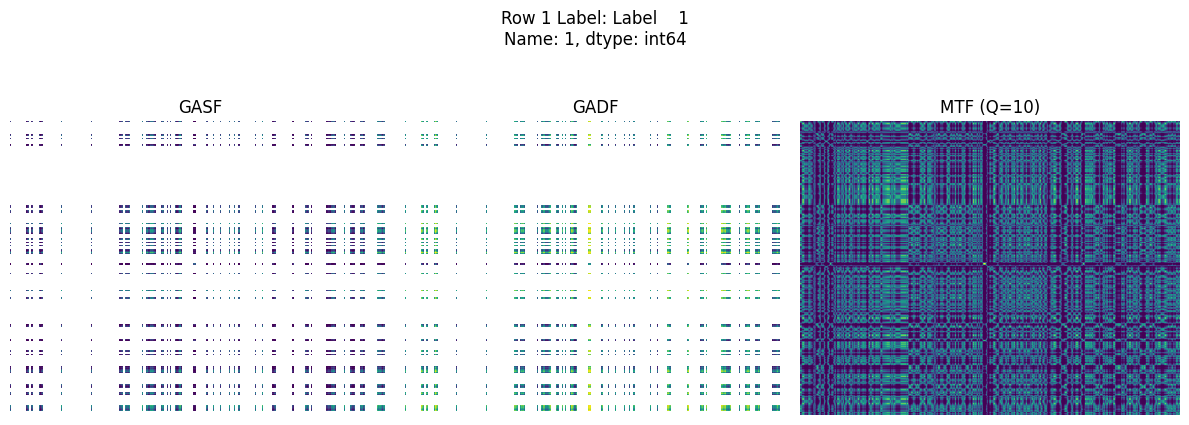

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def gramian_angular_field(signal: np.ndarray):
    # Signal assumed normalized to [0, 1]; rescale to [-1, 1]
    s_scaled = 2 * signal - 1
    phi = np.arccos(s_scaled)
    gasf = np.cos(phi[:, None] + phi[None, :])
    gadf = np.sin(phi[:, None] - phi[None, :])
    return gasf, gadf

def markov_transition_field(signal: np.ndarray, n_bins: int = 10):
    eps = 1e-8
    bins = np.linspace(signal.min(), signal.max() + eps, n_bins + 1)
    lvl = np.digitize(signal, bins) - 1
    # Build transition probabilities
    P = np.zeros((n_bins, n_bins))
    for i in range(len(lvl) - 1):
        P[lvl[i], lvl[i + 1]] += 1
    row_sums = P.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    P /= row_sums
    # Build MTF image
    N = len(signal)
    mtf = np.zeros((N, N))
    for i in range(N):
        for j in range(N):
            mtf[i, j] = P[lvl[i], lvl[j]]
    return mtf

def process_row_with_label(n_bins: int = 10):
    """
    Reads one row from an Excel file (already MinMax normalized [0,1]),
    reads corresponding label from a CSV, and computes + plots GASF, GADF, and MTF.
    
    Returns the 3 matrices and the label.
    """
    # Load data row
    df = pd.read_excel("minmax.xlsx")
    signal = df.iloc[1].astype(float).values
    
    # Load labels
    labels_df = pd.read_csv("idC_with_header.csv")
    label = labels_df.iloc[1]
    
    # Compute fields
    gasf, gadf = gramian_angular_field(signal)
    mtf = markov_transition_field(signal, n_bins=n_bins)
    
    # Plot
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.imshow(gasf, aspect='auto')
    plt.title('GASF')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(gadf, aspect='auto')
    plt.title('GADF')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(mtf, aspect='auto')
    plt.title(f'MTF (Q={n_bins})')
    plt.axis('off')
    
    plt.suptitle(f'Row 1 Label: {label}', y=1.05)
    plt.tight_layout()
    plt.show()
    
    return gasf, gadf, mtf, label

gasf, gadf, mtf, lbl = process_row_with_label(n_bins=10)


In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split

# --- 1. Utility functions for GAF & MTF ---

def gramian_angular_field(signal: np.ndarray):
    s_scaled = 2 * signal - 1  # assume input in [0,1]
    phi = np.arccos(s_scaled)
    gasf = np.cos(phi[:, None] + phi[None, :])
    gadf = np.sin(phi[:, None] - phi[None, :])
    return gasf, gadf


def markov_transition_field(signal: np.ndarray, n_bins: int = 10):
    eps = 1e-8
    bins = np.linspace(signal.min(), signal.max() + eps, n_bins + 1)
    lvl = np.digitize(signal, bins) - 1
    P = np.zeros((n_bins, n_bins))
    for i in range(len(lvl) - 1):
        P[lvl[i], lvl[i + 1]] += 1
    row_sums = P.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    P /= row_sums
    N = len(signal)
    mtf = np.zeros((N, N))
    for i in range(N):
        for j in range(N):
            mtf[i, j] = P[lvl[i], lvl[j]]
    return mtf


# --- 2. Custom Dataset ---
class SpectraDataset(Dataset):
    def __init__(self, data_path, labels_path, n_samples=100, n_bins=10):
        # Load first n_samples
        df = pd.read_excel(data_path, header=None).iloc[:n_samples]
        labels = pd.read_csv(labels_path).iloc[:n_samples]
        self.X = []
        self.y = labels.values.flatten().astype(int)
        for idx in range(len(df)):
            sig = df.iloc[idx].values.astype(float)
            gasf, gadf = gramian_angular_field(sig)
            mtf = markov_transition_field(sig, n_bins=n_bins)
            # stack channels: (3, N, N)
            img = np.stack([gasf, gadf, mtf], axis=0).astype(np.float32)
            self.X.append(img)
        self.X = np.stack(self.X)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


# --- 3. Define PyTorch CNN ---
class SimpleCNN(nn.Module):
    def __init__(self, in_channels=3, num_classes=2):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, 16, kernel_size=3, padding=1)
        self.pool  = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        # Assume input N x N -> after two pools: N/4 x N/4
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc1 = nn.Linear(64, 64)
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        x = F.relu(self.conv3(x))
        x = self.global_pool(x)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x


# --- 4. Training Loop ---

def train_model(data_path, labels_path, n_samples=100, n_bins=10,
                batch_size=8, epochs=20, lr=1e-3, test_split=0.2):
    # Prepare dataset and loaders
    dataset = SpectraDataset(data_path, labels_path, n_samples, n_bins)
    test_size = int(len(dataset) * test_split)
    train_size = len(dataset) - test_size
    train_ds, test_ds = random_split(dataset, [train_size, test_size])

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    test_loader  = DataLoader(test_ds, batch_size=batch_size)

    # Device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = SimpleCNN(in_channels=3, num_classes=len(np.unique(dataset.y)))
    model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * batch_x.size(0)
        epoch_loss = running_loss / train_size

        # evaluation
        model.eval()
        correct = 0
        with torch.no_grad():
            for batch_x, batch_y in test_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                outputs = model(batch_x)
                preds = outputs.argmax(dim=1)
                correct += (preds == batch_y).sum().item()
        acc = correct / test_size
        print(f"Epoch {epoch}/{epochs} - Loss: {epoch_loss:.4f} - Val Acc: {acc:.4f}")

    return model


if __name__ == "__main__":
    # Replace paths as needed
    trained_model = train_model(
        data_path="minmax.xlsx",
        labels_path="idC_with_header.csv",
        n_samples=100,
        n_bins=10,
        batch_size=8,
        epochs=20
    )
    # You can save: torch.save(trained_model.state_dict(), "nir_cnn.pth")


C:\Users\Admin\AppData\Local\Temp\ipykernel_15548\4214993915.py:12: RuntimeWarning: invalid value encountered in arccos
  phi = np.arccos(s_scaled)


RuntimeError: expected scalar type Long but found Int